# 🚗 Vietnamese License Plate Detection - YOLOv11 Training

## Setup

In [ ]:
# Install dependencies
!pip install ultralytics wandb -q

# Check GPU
!nvidia-smi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.9 MB/s eta 0:00:00
Sun Jun 21 10:55:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   30C    P0             47W /  600W |       0MiB /  97887MiB |      0

## 1. Upload Dataset

In [ ]:
from google.colab import files
import zipfile
import os

# Option 1: Upload ZIP file
print("Upload your dataset ZIP file...")
uploaded = files.upload()

# Extract
for filename in uploaded.keys():
    print(f"Extracting {filename}...")
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall('/content/dataset/')
    print("Done!")

Upload your dataset ZIP file...


Saving LicensePlateDetectionDataset.zip to LicensePlateDetectionDataset.zip
Extracting LicensePlateDetectionDataset.zip...
Done!


In [ ]:
# Option 2: Download from Google Drive (faster)
# Replace with your Drive file ID
!pip install gdown -q

# Example: Download dataset from Google Drive
# FILE_ID = "your_file_id_here"
# !gdown --id {FILE_ID}

# Then extract
# !unzip dataset.zip -d /content/dataset/

## 2. Create data.yaml

In [ ]:
# Update these paths based on your dataset structure
data_yaml = """
# Vietnamese License Plate Detection Dataset

path: /content/dataset
train: images/train
val: images/val
test: images/test

nc: 1
names:
  0: license_plate
"""

# Save data.yaml
with open('/content/data.yaml', 'w') as f:
    f.write(data_yaml)

print("data.yaml created!")

data.yaml created!


## 3. Verify Dataset

In [ ]:
import os
from pathlib import Path

base = Path('/content/dataset/')

for split in ['train', 'val', 'test']:
    img_dir = base / 'images' / split
    lbl_dir = base / 'labels' / split

    if img_dir.exists() and lbl_dir.exists():
        imgs = len(list(img_dir.glob('*.jpg'))) + len(list(img_dir.glob('*.png')))
        lbls = len(list(lbl_dir.glob('*.txt')))
        print(f"{split.upper()}: {imgs} images, {lbls} labels")
    else:
        print(f"{split.upper()}: NOT FOUND")

TRAIN: 6607 images, 6607 labels
VAL: 814 images, 814 labels
TEST: 838 images, 838 labels


In [ ]:
import os
import zipfile
import shutil

print("Đang xử lý lại file zip từ Windows...")

# Xóa thư mục dataset cũ nếu đã giải nén sai
if os.path.exists('/content/dataset'):
    shutil.rmtree('/content/dataset')

os.makedirs('/content/dataset', exist_ok=True)

# Đọc và giải nén lại với đường dẫn chuẩn
with zipfile.ZipFile('/content/LicensePlateDetectionDataset.zip', 'r') as zip_ref:
    for member in zip_ref.namelist():
        # Sửa dấu \ thành / để Linux hiểu được thư mục
        correct_path = member.replace('\\', '/')
        target_path = os.path.join('/content/dataset', correct_path)

        # Tạo thư mục chứa file
        os.makedirs(os.path.dirname(target_path), exist_ok=True)

        # Chỉ ghi dữ liệu nếu không phải là thư mục rỗng
        if not member.endswith('/') and not member.endswith('\\'):
            with open(target_path, 'wb') as outfile:
                outfile.write(zip_ref.read(member))

print("Giải nén thành công! Kiểm tra lại thư mục:")
!ls -l /content/dataset/

Đang xử lý lại file zip từ Windows...
Giải nén thành công! Kiểm tra lại thư mục:
total 8
drwxr-xr-x 5 root root 4096 Jun 21 12:04 images
drwxr-xr-x 5 root root 4096 Jun 21 12:04 labels


## 4. Train YOLOv11

In [ ]:
from ultralytics import YOLO

# Load pretrained model (s = small, recommended)
model = YOLO('yolo11s.pt')

# Train
results = model.train(
    data='/content/data.yaml',
    epochs=100,           # Adjust as needed
    batch=16,            # Adjust based on GPU memory
    imgsz=640,
    device=0,
    project='/content/runs',
    name='plate_detection',
    exist_ok=True,

    # Optimizer
    optimizer='AdamW',
    lr0=0.001,

    # Augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,

    # Settings
    save=True,
    save_json=True,
    patience=50,
    verbose=True,
)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW

## 5. View Results

In [ ]:
# Print metrics
print("Training complete!")
print(f"\nResults saved to: /content/runs/plate_detection")

# Best weights
print("\nBest model: /content/runs/plate_detection/weights/best.pt")
print("Last model: /content/runs/plate_detection/weights/last.pt")

Training complete!

Results saved to: /content/runs/plate_detection

Best model: /content/runs/plate_detection/weights/best.pt
Last model: /content/runs/plate_detection/weights/last.pt


## 6. Download Model

In [ ]:
# Download best model
from google.colab import files

!cp /content/runs/plate_detection/weights/best.pt /content/best_plate_detector.pt
files.download('/content/best_plate_detector.pt')

print("Model downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model downloaded!


## 7. Validate on Test Set

In [ ]:
# Load best model
best_model = YOLO('/content/runs/plate_detection/weights/best.pt')

# Validate
val_results = best_model.val(
    data='/content/data.yaml',
    split='test',
    device=0
)

print(f"\nTest Set Results:")
print(f"mAP@0.5: {val_results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {val_results.box.map:.4f}")

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2864.9±1548.4 MB/s, size: 45.1 KB)
val: Scanning /content/dataset/labels/test... 838 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 838/838 4.7Kit/s 0.2s
val: New cache created: /content/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 53/53 31.4it/s 1.7s
                   all        838        849      0.995      0.994      0.994      0.718
Speed: 0.2ms preprocess, 0.6ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val

Test Set Results:
mAP@0.5: 0.9945
mAP@0.5:0.95: 0.7183


## 8. Export to ONNX (for deployment)

In [ ]:
# Export to ONNX
best_model.export(format='onnx')

print("ONNX model exported!")
files.download('/content/runs/plate_detection/weights/best.onnx')

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (AMD EPYC 9B45)

PyTorch: starting from '/content/runs/plate_detection/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (18.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 175ms
Prepared 4 packages in 479ms
Installed 4 packages in 134ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 2.0s, saved as '/content/runs/plate_detection/weights/best.onnx' (36.2 MB)

Export complete (2.1s)
Results saved to /content/runs/plate_detection/weights/best.onnx
Predict:         yolo p

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
from google.colab import files

print("Đang nén toàn bộ kết quả huấn luyện...")
# Nén thư mục kết quả thành file zip
shutil.make_archive('/content/plate_detection_results', 'zip', '/content/runs/plate_detection')

print("Đang tải về máy tính của bạn...")
# Tải file zip về máy local
files.download('/content/plate_detection_results.zip')

Đang nén toàn bộ kết quả huấn luyện...
Đang tải về máy tính của bạn...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Hướng dẫn sử dụng mô hình trên Cursor

**Bước 1:** Trong Cursor, tạo một thư mục dự án mới. Kéo thả file `best.pt` (hoặc `best.onnx`) vừa tải về vào thư mục này.

**Bước 2:** Mở Terminal trong Cursor và cài đặt thư viện Ultralytics (nếu chưa có):
```bash
pip install ultralytics
```

**Bước 3:** Tạo một file `predict.py` và dán đoạn code sau để chạy thử với một ảnh biển số xe trên máy bạn:

```python
from ultralytics import YOLO

# 1. Load mô hình đã train (đảm bảo đường dẫn file .pt chính xác)
model = YOLO('best.pt')

# 2. Chạy dự đoán trên một bức ảnh (thay bằng đường dẫn ảnh thực tế)
image_path = 'test_image.jpg'
results = model(image_path)

# 3. Hiển thị và lưu kết quả
for result in results:
    result.show()  # Mở cửa sổ popup hiển thị ảnh đã vẽ bounding box
    result.save(filename='result.jpg')  # Lưu ảnh kết quả ra file
```

Bây giờ bạn chỉ cần chạy `python predict.py` trong Cursor là xong!

## 9. Kiểm tra mô hình với ảnh thực tế (Test with Real Images)
Chạy cell bên dưới để tải lên một bức ảnh từ máy tính của bạn và xem kết quả mô hình nhận diện trực tiếp trên Colab.

Vui lòng tải lên một bức ảnh để kiểm tra:


Saving brightnessquandoi55.jpg to brightnessquandoi55.jpg

Đang chạy mô hình nhận diện...

image 1/1 /content/brightnessquandoi55.jpg: 480x640 1 license_plate, 19.5ms
Speed: 0.8ms preprocess, 19.5ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)


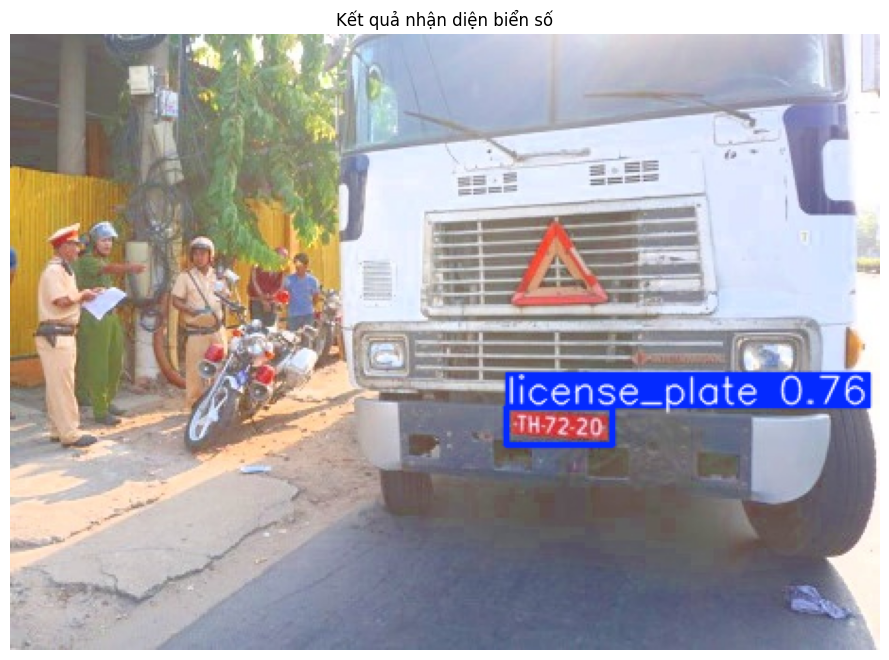

In [ ]:
from google.colab import files
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

print("Vui lòng tải lên một bức ảnh để kiểm tra:")
uploaded = files.upload()

if uploaded:
    # Lấy tên file vừa upload
    image_name = list(uploaded.keys())[0]

    print("\nĐang chạy mô hình nhận diện...")
    # Load mô hình tốt nhất đã train
    model = YOLO('/content/runs/plate_detection/weights/best.pt')

    # Chạy dự đoán
    results = model(image_name)

    # Vẽ bounding box lên ảnh
    res_img = results[0].plot()

    # Chuyển đổi hệ màu BGR (OpenCV) sang RGB (Matplotlib) để hiển thị đúng màu
    res_img_rgb = cv2.cvtColor(res_img, cv2.COLOR_BGR2RGB)

    # Hiển thị kết quả
    plt.figure(figsize=(12, 8))
    plt.imshow(res_img_rgb)
    plt.axis('off')
    plt.title("Kết quả nhận diện biển số")
    plt.show()
else:
    print("Bạn chưa tải ảnh lên.")

## 10. Xem chi tiết các chỉ số đánh giá (mAP, Precision, Recall, F1-Score)

In [ ]:
from ultralytics import YOLO

# Tải lại mô hình tốt nhất
model = YOLO('/content/runs/plate_detection/weights/best.pt')

# Đánh giá trên tập test
print("Đang đánh giá mô hình trên tập test để tính toán các chỉ số...")
metrics = model.val(data='/content/data.yaml', split='test', device=0)

# Lấy các chỉ số từ metrics dictionary của Ultralytics
precision = metrics.results_dict['metrics/precision(B)']
recall = metrics.results_dict['metrics/recall(B)']
map50 = metrics.results_dict['metrics/mAP50(B)']

# Tính F1-score
if (precision + recall) > 0:
    f1_score = 2 * (precision * recall) / (precision + recall)
else:
    f1_score = 0.0

print(f"\n" + "="*40)
print(f"--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---")
print(f"="*40)
print(f"Precision (Độ chính xác) : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall (Độ phủ)          : {recall:.4f} ({recall*100:.2f}%)")
print(f"mAP@0.5                  : {map50:.4f} ({map50*100:.2f}%)")
print(f"F1-score                 : {f1_score:.4f} ({f1_score*100:.2f}%)")
print("="*40)

Đang đánh giá mô hình trên tập test để tính toán các chỉ số...
Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2902.7±1173.2 MB/s, size: 35.8 KB)
val: Scanning /content/dataset/labels/test.cache... 838 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 838/838 439.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 53/53 32.7it/s 1.6s
                   all        838        849      0.995      0.994      0.994      0.718
Speed: 0.2ms preprocess, 0.6ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/runs/detect/val-2

--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---
Precision (Độ chính xác) : 0.9949 (99.49%)
Recall (Độ phủ)          : 0.9941 (99.41%)
mAP@0.5                  : 0.9945 (99.45%)
F1-sc

## 11. Tích hợp Nhận diện ký tự (OCR) với EasyOCR
Phần này sẽ hướng dẫn bạn cách dùng YOLO để tìm biển số, sau đó cắt ảnh biển số và đưa vào EasyOCR để đọc chữ/số.

In [ ]:
# Cài đặt thư viện EasyOCR
!pip install easyocr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 113.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 37.6 MB/s eta 0:00:00


Đang khởi tạo bộ đọc EasyOCR...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete
Đang chạy mô hình YOLO...

image 1/1 /content/brightnessquandoi55.jpg: 480x640 1 license_plate, 3.1ms
Speed: 1.0ms preprocess, 3.1ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)
OCR đọc được: 'H72-20' - Độ tin cậy: 0.49


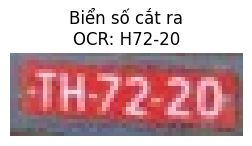

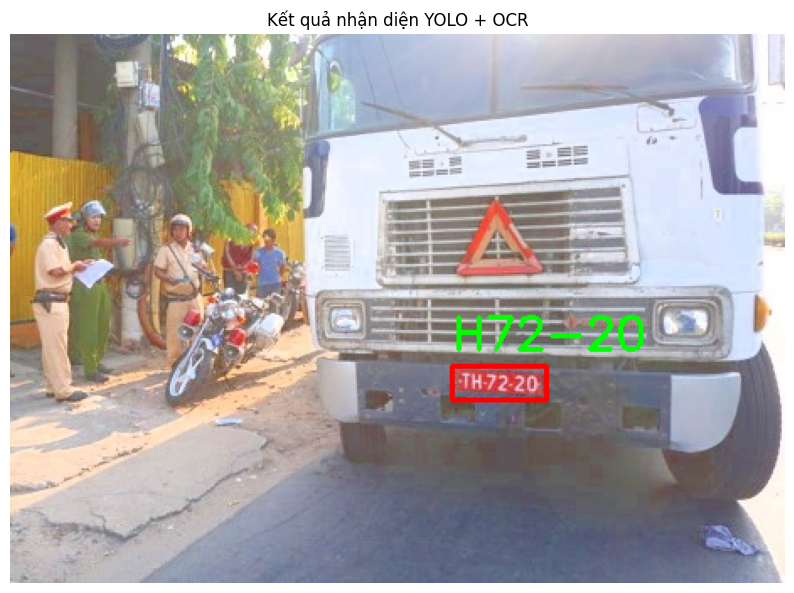

In [ ]:
import cv2
import easyocr
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("Đang khởi tạo bộ đọc EasyOCR...")
# Khởi tạo EasyOCR (chỉ dùng tiếng Anh 'en' vì biển số xe chủ yếu là chữ cái Latinh và số)
reader = easyocr.Reader(['en'], gpu=True)

# Load mô hình YOLO
model = YOLO('/content/runs/plate_detection/weights/best.pt')

# Sử dụng lại bức ảnh bạn đã tải lên trước đó
image_path = '/content/brightnessquandoi55.jpg'

print("\nĐang chạy mô hình YOLO...")
# 1. Chạy YOLO để tìm biển số
results = model(image_path)

# Đọc ảnh gốc bằng OpenCV để xử lý cắt và vẽ
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Xử lý từng biển số được tìm thấy
for result in results:
    boxes = result.boxes
    for box in boxes:
        # Lấy tọa độ bounding box [x_min, y_min, x_max, y_max]
        x1, y1, x2, y2 = box.xyxy[0]
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

        # Cắt ảnh vùng biển số
        plate_crop = img[y1:y2, x1:x2]

        # 3. Chạy EasyOCR trên vùng ảnh vừa cắt
        ocr_results = reader.readtext(plate_crop)

        detected_text = ""
        for (bbox, text, prob) in ocr_results:
            detected_text += text + " "
            print(f"OCR đọc được: '{text}' - Độ tin cậy: {prob:.2f}")

        # Làm sạch chuỗi (xóa khoảng trắng thừa)
        detected_text = detected_text.strip()

        # 4. Vẽ lại kết quả lên ảnh gốc (Khung và Chữ)
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 2)  # Vẽ khung màu xanh dương
        # Hiển thị chữ ngay phía trên biển số
        cv2.putText(img_rgb, detected_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

        # Hiển thị ảnh biển số bị cắt (để dễ kiểm tra OCR có đọc đúng ảnh không)
        plt.figure(figsize=(3, 3))
        plt.imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB))
        plt.title(f"Biển số cắt ra\nOCR: {detected_text}")
        plt.axis('off')
        plt.show()

# Hiển thị kết quả cuối cùng trên toàn bộ ảnh
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title("Kết quả nhận diện YOLO + OCR")
plt.axis('off')
plt.show()

## 12. Tích hợp Nhận diện ký tự (OCR) với PaddleOCR
PaddleOCR thường cho độ chính xác cao hơn và hỗ trợ nhận diện chữ nghiêng (Angle Classification) rất tốt. Dưới đây là cách kết hợp YOLOv11 và PaddleOCR.

In [ ]:
# Cài đặt PaddlePaddle (phiên bản 2.6.2 để tránh lỗi tương thích) và thư viện PaddleOCR
!python -m pip install paddlepaddle==2.6.2 -q
!pip install "paddleocr>=2.0.1" -q

Đang khởi tạo bộ đọc PaddleOCR...
[2026/06/21 17:23:21] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.1, det_db_box_thresh=0.3, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_te

Saving boderngoaigiao12.jpg to boderngoaigiao12 (1).jpg

Đang chạy mô hình YOLO...

image 1/1 /content/boderngoaigiao12 (1).jpg: 448x640 2 license_plates, 11.2ms
Speed: 2.9ms preprocess, 11.2ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)
[2026/06/21 17:23:53] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 17:23:53] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.08547830581665039
[2026/06/21 17:23:53] ppocr DEBUG: rec_res num  : 1, elapsed : 0.05163836479187012
[2026/06/21 17:23:53] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 17:23:53] ppocr DEBUG: dt_boxes num : 2, elapsed : 0.04611921310424805
[2026/06/21 17:23:53] ppocr DEBUG: rec_res num  : 2, elapsed : 0.10059332847595215

Đã phát hiện tổng cộng 2 biển số.


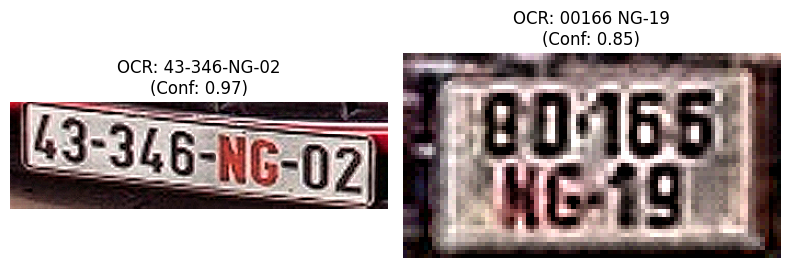

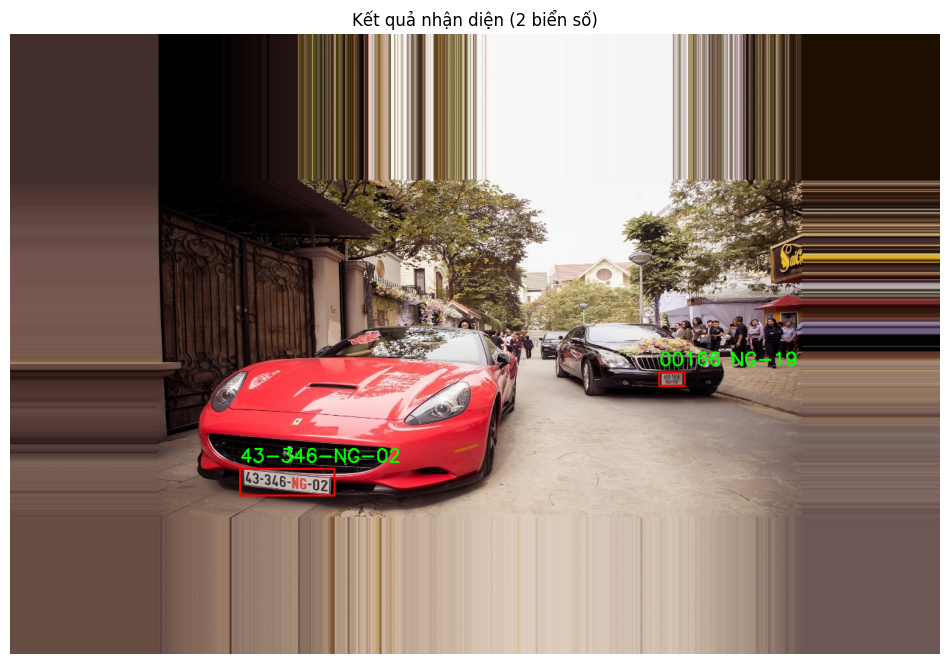

In [ ]:
# ==============================================================================
# LƯU Ý QUAN TRỌNG: Nếu bạn gặp lỗi "ValueError: numpy.dtype size changed..."
# Vui lòng vào menu Runtime -> Restart session (Khởi động lại phiên)
# Sau đó chạy lại trực tiếp cell này để môi trường nhận diện đúng NumPy 1.x.
# ==============================================================================

!pip uninstall -y paddleocr paddlex -q
!python -m pip install paddlepaddle==2.6.2 -q
!pip install "paddleocr==2.7.3" ultralytics "numpy<2.0.0" -q

import sys
# Xóa cache module nếu đã được load trước đó để tránh xung đột phần Python
for key in list(sys.modules.keys()):
    if 'paddleocr' in key or 'paddlex' in key:
        del sys.modules[key]

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from paddleocr import PaddleOCR
from google.colab import files

# Hàm tăng cường chất lượng ảnh trước khi OCR
def enhance_image(img):
    # 1. Phóng to ảnh (Upscaling) 2.5 lần bằng nội suy Bicubic
    img = cv2.resize(img, None, fx=2.5, fy=2.5, interpolation=cv2.INTER_CUBIC)

    # 2. Tăng cường độ tương phản cục bộ (CLAHE) trên kênh sáng (Value)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    v = clahe.apply(v)
    hsv = cv2.merge((h, s, v))
    img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    # 3. Làm sắc nét (Sharpening kernel)
    kernel = np.array([[0, -1, 0],
                       [-1, 5,-1],
                       [0, -1, 0]])
    img = cv2.filter2D(img, -1, kernel)

    return img

print("Đang khởi tạo bộ đọc PaddleOCR...")
# Khởi tạo PaddleOCR (dùng tiếng Anh 'en' vì biển số chủ yếu là số và chữ Latinh)
# Thêm use_gpu=False để tránh lỗi CUDNN mismatch trên môi trường Colab
# Tối ưu hóa: giảm det_db_thresh và det_db_box_thresh để tăng độ nhạy với ảnh mờ
ocr = PaddleOCR(
    use_textline_orientation=True,
    lang='en',
    use_gpu=False,
    det_db_thresh=0.1,      # Mặc định 0.3. Giảm xuống giúp phát hiện nét chữ mờ/nhạt hơn
    det_db_box_thresh=0.3   # Mặc định 0.6. Giảm xuống để không loại bỏ các vùng text bị mờ
)

# Load mô hình YOLO tốt nhất đã train
model = YOLO('/content/best.pt')

print("Vui lòng tải lên bức ảnh bạn muốn kiểm tra:")
uploaded = files.upload()

if uploaded:
    image_path = list(uploaded.keys())[0]

    print("\nĐang chạy mô hình YOLO...")
    # 1. Chạy YOLO để tìm bounding box
    results = model(image_path)

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plates_data = []

    # 2. Xử lý từng biển số được tìm thấy
    for result in results:
        boxes = result.boxes
        for box in boxes:
            # Tọa độ bounding box
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            yolo_conf = float(box.conf[0])

            # Cắt ảnh vùng biển số
            plate_crop = img[y1:y2, x1:x2]

            # Kiểm tra nếu vùng cắt quá nhỏ/không hợp lệ
            if plate_crop.shape[0] == 0 or plate_crop.shape[1] == 0:
                continue

            # TĂNG CƯỜNG ẢNH TRƯỚC KHI OCR
            enhanced_crop = enhance_image(plate_crop)

            # 3. Chạy PaddleOCR trên ảnh đã tăng cường
            ocr_results = ocr.ocr(enhanced_crop, cls=True)

            detected_text = ""
            ocr_conf = 0.0
            if ocr_results and ocr_results[0]:
                texts = [line[1][0] for line in ocr_results[0]]
                confs = [line[1][1] for line in ocr_results[0]]
                detected_text = " ".join(texts)
                ocr_conf = sum(confs) / len(confs) if confs else 0.0

            detected_text = detected_text.strip()

            plates_data.append({
                'box': (x1, y1, x2, y2),
                'crop': enhanced_crop,  # Hiển thị ảnh đã xử lý
                'text': detected_text,
                'ocr_conf': ocr_conf
            })

            # 4. Vẽ lại kết quả lên ảnh gốc
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 2)  # Vẽ khung xanh dương
            cv2.putText(img_rgb, detected_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # 5. Hiển thị tất cả ảnh biển số bị cắt (dạng Grid)
    num_plates = len(plates_data)
    print(f"\nĐã phát hiện tổng cộng {num_plates} biển số.")

    if num_plates > 0:
        cols = min(num_plates, 4)
        rows = (num_plates + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
        if num_plates == 1:
            axes = [axes]
        elif rows > 1:
            axes = axes.flatten()

        for i, data in enumerate(plates_data):
            axes[i].imshow(cv2.cvtColor(data['crop'], cv2.COLOR_BGR2RGB))
            axes[i].set_title(f"OCR: {data['text']}\n(Conf: {data['ocr_conf']:.2f})")
            axes[i].axis('off')

        # Ẩn các ô trống nếu có
        for j in range(num_plates, len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        plt.show()

    # Hiển thị kết quả cuối cùng trên toàn bộ ảnh
    plt.figure(figsize=(12, 10))
    plt.imshow(img_rgb)
    plt.title(f"Kết quả nhận diện ({num_plates} biển số)")
    plt.axis('off')
    plt.show()
else:
    print("Bạn chưa tải ảnh lên!")

## 13. Lưu kết quả ra file CSV
Chạy cell dưới đây để xuất kết quả nhận diện (bao gồm chữ số, độ tin cậy và tọa độ) ra file CSV và tải về máy.

In [ ]:
import pandas as pd
from google.colab import files

# Kiểm tra xem có dữ liệu biển số từ cell trước không
if 'plates_data' in locals() and len(plates_data) > 0:
    csv_data = []
    for i, data in enumerate(plates_data):
        x1, y1, x2, y2 = data['box']
        csv_data.append({
            'STT': i + 1,
            'Biển số': data['text'],
            'Độ tin cậy OCR': round(data['ocr_conf'], 4),
            'Tọa độ (x1, y1, x2, y2)': f"({x1}, {y1}, {x2}, {y2})"
        })

    # Tạo DataFrame từ danh sách kết quả
    df = pd.DataFrame(csv_data)

    # Lưu ra file CSV (dùng utf-8-sig để hiển thị tiếng Việt tốt trên Excel nếu có)
    csv_filename = 'ket_qua_nhan_dien_bien_so.csv'
    df.to_csv(csv_filename, index=False, encoding='utf-8-sig')

    print(f"Đã lưu thành công {len(plates_data)} kết quả vào file: {csv_filename}\n")

    # Hiển thị bảng kết quả ngay trên Colab
    display(df)

    # Tải file về máy tính
    print("\nĐang tải file CSV về máy...")
    files.download(csv_filename)
else:
    print("Không tìm thấy dữ liệu nhận diện. Vui lòng chạy cell nhận diện (PaddleOCR hoặc EasyOCR) thành công trước khi xuất file.")


Đã lưu thành công 2 kết quả vào file: ket_qua_nhan_dien_bien_so.csv



,STT,Biển số,Độ tin cậy OCR,"Tọa độ (x1, y1, x2, y2)"
0,1,43-346-NG-02,0.9749,"(336, 636, 474, 675)"
1,2,00166 NG-19,0.8479,"(949, 495, 986, 515)"



Đang tải file CSV về máy...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 14. Thử nghiệm với ảnh thiếu sáng (Low Light / Night Vision)
Kết hợp **Gamma Correction** (để tăng sáng vùng tối) và **CLAHE mạnh hơn** (để tăng tương phản) giúp PaddleOCR có thể đọc được biển số trong điều kiện ánh sáng yếu hoặc chụp buổi tối.

Tham số Gamma hiện tại: 3.0
Vui lòng tải lên bức ảnh THIẾU SÁNG bạn muốn kiểm tra:


Saving brightnessquandoi18.jpg to brightnessquandoi18.jpg

Đang chạy mô hình YOLO...

image 1/1 /content/brightnessquandoi18.jpg: 416x640 1 license_plate, 14.0ms
Speed: 3.2ms preprocess, 14.0ms inference, 1.8ms postprocess per image at shape (1, 3, 416, 640)
[2026/06/21 17:49:24] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 17:49:24] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.061304569244384766
[2026/06/21 17:49:24] ppocr DEBUG: rec_res num  : 1, elapsed : 0.04706859588623047

Đã phát hiện tổng cộng 1 biển số.


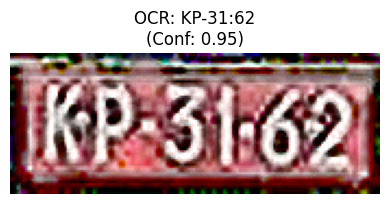

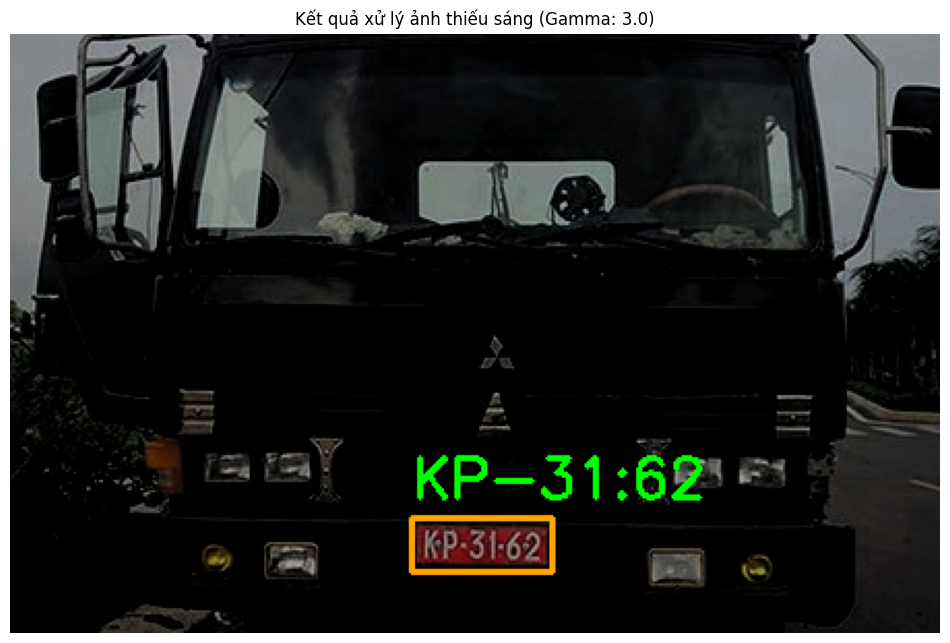

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# @title Cấu hình tăng sáng và Chạy nhận diện
gamma_value = 1 # @param {type:"slider", min:1.0, max:5.0, step:0.1}

# Hàm xử lý đặc biệt cho ảnh thiếu sáng
def enhance_low_light_image(img, gamma=2.0):
    # 1. Cân bằng Gamma (Tăng sáng các vùng tối mà không làm lóa vùng sáng)
    # Gamma > 1 sẽ làm ảnh sáng lên. Có thể điều chỉnh tham số gamma này tùy độ tối của ảnh.
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    img = cv2.LUT(img, table)

    # 2. Phóng to ảnh (Upscaling) 2.5 lần bằng nội suy Bicubic
    img = cv2.resize(img, None, fx=2.5, fy=2.5, interpolation=cv2.INTER_CUBIC)

    # 3. CLAHE (Tăng cường độ tương phản) với mức độ kéo mạnh hơn (clipLimit=3.0)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    v = clahe.apply(v)
    hsv = cv2.merge((h, s, v))
    img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    # 4. Làm sắc nét (Sharpening)
    kernel = np.array([[0, -1, 0],
                       [-1, 5,-1],
                       [0, -1, 0]])
    img = cv2.filter2D(img, -1, kernel)
    return img

print(f"Tham số Gamma hiện tại: {gamma_value}")
print("Vui lòng tải lên bức ảnh THIẾU SÁNG bạn muốn kiểm tra:")
uploaded = files.upload()

if uploaded:
    image_path = list(uploaded.keys())[0]

    print("\nĐang chạy mô hình YOLO...")
    # Chạy YOLO để tìm bounding box
    results = model(image_path)

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plates_data = [] # Lưu lại để có thể dùng cell xuất CSV ở trên

    # Xử lý từng biển số được tìm thấy
    for result in results:
        boxes = result.boxes
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            plate_crop = img[y1:y2, x1:x2]
            if plate_crop.shape[0] == 0 or plate_crop.shape[1] == 0:
                continue

            # TĂNG CƯỜNG ẢNH THIẾU SÁNG với gamma tùy chỉnh
            enhanced_crop = enhance_low_light_image(plate_crop, gamma=gamma_value)

            # Chạy PaddleOCR trên ảnh đã tăng cường
            ocr_results = ocr.ocr(enhanced_crop, cls=True)

            detected_text = ""
            ocr_conf = 0.0
            if ocr_results and ocr_results[0]:
                texts = [line[1][0] for line in ocr_results[0]]
                confs = [line[1][1] for line in ocr_results[0]]
                detected_text = " ".join(texts).strip()
                ocr_conf = sum(confs) / len(confs) if confs else 0.0

            plates_data.append({
                'box': (x1, y1, x2, y2),
                'crop': enhanced_crop,
                'text': detected_text,
                'ocr_conf': ocr_conf
            })

            # Vẽ khung chữ nhật và kết quả chữ
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 165, 0), 2)  # Vẽ khung màu cam cho dễ nhìn trong tối
            cv2.putText(img_rgb, detected_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # Hiển thị ảnh biển số bị cắt
    num_plates = len(plates_data)
    print(f"\nĐã phát hiện tổng cộng {num_plates} biển số.")

    if num_plates > 0:
        cols = min(num_plates, 4)
        rows = (num_plates + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
        if num_plates == 1: axes = [axes]
        elif rows > 1: axes = axes.flatten()

        for i, data in enumerate(plates_data):
            axes[i].imshow(cv2.cvtColor(data['crop'], cv2.COLOR_BGR2RGB))
            axes[i].set_title(f"OCR: {data['text']}\n(Conf: {data['ocr_conf']:.2f})")
            axes[i].axis('off')

        for j in range(num_plates, len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        plt.show()

    # Hiển thị toàn cảnh
    plt.figure(figsize=(12, 10))
    plt.imshow(img_rgb)
    plt.title(f"Kết quả xử lý ảnh thiếu sáng (Gamma: {gamma_value})")
    plt.axis('off')
    plt.show()
else:
    print("Bạn chưa tải ảnh lên!")

## 15. So sánh hiệu quả tăng cường ảnh (Original vs Enhanced)
Đánh giá sự cải thiện về độ tin cậy OCR khi sử dụng bộ lọc Gamma và CLAHE trên ảnh thiếu sáng.

--- SO SÁNH ĐỘ TIN CẬY OCR TRƯỚC VÀ SAU KHI XỬ LÝ (Gamma = 3.0) ---

[2026/06/21 18:03:42] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 18:03:42] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.01570606231689453
[2026/06/21 18:03:42] ppocr DEBUG: rec_res num  : 1, elapsed : 0.047493934631347656
[2026/06/21 18:03:42] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 18:03:42] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.015520572662353516
[2026/06/21 18:03:42] ppocr DEBUG: rec_res num  : 1, elapsed : 0.04490327835083008
Biển số 1:
  - Ảnh GỐC      : Nhận diện = 'KP-31-62' | Độ tin cậy = 0.8386
  - Ảnh XỬ LÝ    : Nhận diện = 'KP-31:62' | Độ tin cậy = 0.9472
  => Thay đổi độ tin cậy: +12.95%
------------------------------------------------------------


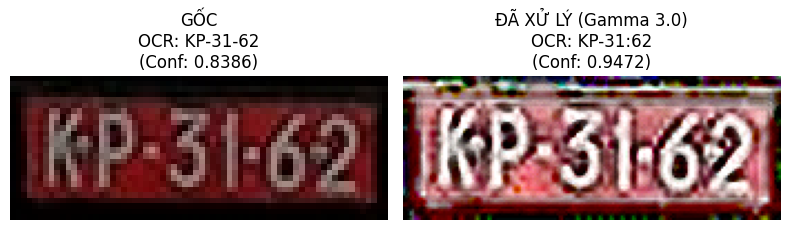

In [ ]:
import cv2
import matplotlib.pyplot as plt

print(f"--- SO SÁNH ĐỘ TIN CẬY OCR TRƯỚC VÀ SAU KHI XỬ LÝ (Gamma = {gamma_value}) ---\n")

if 'image_path' in locals() and 'results' in locals():
    img = cv2.imread(image_path)

    plate_idx = 1
    for result in results:
        boxes = result.boxes
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            plate_crop = img[y1:y2, x1:x2]

            if plate_crop.shape[0] == 0 or plate_crop.shape[1] == 0:
                continue

            # 1. OCR trên ảnh GỐC (chưa xử lý)
            ocr_results_raw = ocr.ocr(plate_crop, cls=True)
            text_raw = ""
            conf_raw = 0.0
            if ocr_results_raw and ocr_results_raw[0]:
                texts = [line[1][0] for line in ocr_results_raw[0]]
                confs = [line[1][1] for line in ocr_results_raw[0]]
                text_raw = " ".join(texts).strip()
                conf_raw = sum(confs) / len(confs) if confs else 0.0

            # 2. OCR trên ảnh ĐÃ TĂNG CƯỜNG
            enhanced_crop = enhance_low_light_image(plate_crop, gamma=gamma_value)
            ocr_results_enh = ocr.ocr(enhanced_crop, cls=True)
            text_enh = ""
            conf_enh = 0.0
            if ocr_results_enh and ocr_results_enh[0]:
                texts = [line[1][0] for line in ocr_results_enh[0]]
                confs = [line[1][1] for line in ocr_results_enh[0]]
                text_enh = " ".join(texts).strip()
                conf_enh = sum(confs) / len(confs) if confs else 0.0

            # In text so sánh
            print(f"Biển số {plate_idx}:")
            print(f"  - Ảnh GỐC      : Nhận diện = '{text_raw}' | Độ tin cậy = {conf_raw:.4f}")
            print(f"  - Ảnh XỬ LÝ    : Nhận diện = '{text_enh}' | Độ tin cậy = {conf_enh:.4f}")

            # Cải thiện: Tính % tăng trưởng
            if conf_raw > 0:
                improvement = ((conf_enh - conf_raw) / conf_raw) * 100
                print(f"  => Thay đổi độ tin cậy: {improvement:+.2f}%")
            print("-" * 60)

            # Hiển thị ảnh so sánh trực quan
            fig, axes = plt.subplots(1, 2, figsize=(8, 4))
            axes[0].imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB))
            axes[0].set_title(f"GỐC\nOCR: {text_raw}\n(Conf: {conf_raw:.4f})")
            axes[0].axis('off')

            axes[1].imshow(cv2.cvtColor(enhanced_crop, cv2.COLOR_BGR2RGB))
            axes[1].set_title(f"ĐÃ XỬ LÝ (Gamma {gamma_value})\nOCR: {text_enh}\n(Conf: {conf_enh:.4f})")
            axes[1].axis('off')

            plt.tight_layout()
            plt.show()

            plate_idx += 1
else:
    print("Vui lòng chạy cell Nhận diện ảnh thiếu sáng trước để có dữ liệu đối chiếu!")

## 16. So sánh độ tin cậy OCR cho nhiều ảnh (Biểu đồ)
Tải lên nhiều ảnh để đánh giá tổng quan hiệu quả của bộ lọc tăng cường thông qua biểu đồ.

Vui lòng tải lên NHIỀU bức ảnh để so sánh:


Saving brightnessquandoi16.jpg to brightnessquandoi16.jpg
Saving brightnessquandoi18.jpg to brightnessquandoi18 (1).jpg
Saving brightnessquandoi20.jpg to brightnessquandoi20.jpg
Saving brightnessquandoi32.jpg to brightnessquandoi32 (1).jpg

Đang xử lý ảnh: brightnessquandoi16.jpg

image 1/1 /content/brightnessquandoi16.jpg: 448x640 1 license_plate, 13.5ms
Speed: 2.5ms preprocess, 13.5ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)
[2026/06/21 18:05:34] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 18:05:34] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.019032716751098633
[2026/06/21 18:05:34] ppocr DEBUG: rec_res num  : 0, elapsed : 9.5367431640625e-07
[2026/06/21 18:05:34] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 18:05:34] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.01734614372253418
[2026/06/21 18:05:34] ppocr DEBUG

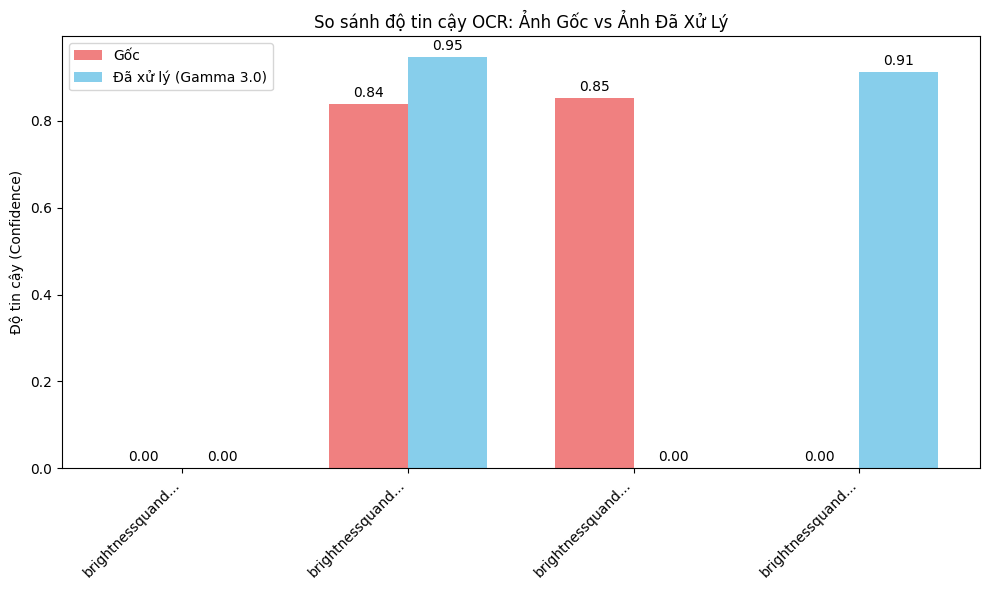

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

print("Vui lòng tải lên NHIỀU bức ảnh để so sánh:")
uploaded_multi = files.upload()

if uploaded_multi:
    image_names = []
    raw_confs = []
    enh_confs = []

    for img_name in uploaded_multi.keys():
        print(f"\nĐang xử lý ảnh: {img_name}")
        results_multi = model(img_name)
        img = cv2.imread(img_name)

        # Lấy biển số đầu tiên tìm thấy để so sánh
        plate_found = False
        for result in results_multi:
            if plate_found:
                break
            boxes = result.boxes
            for box in boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                plate_crop = img[y1:y2, x1:x2]

                if plate_crop.shape[0] == 0 or plate_crop.shape[1] == 0:
                    continue

                # OCR gốc
                ocr_results_raw = ocr.ocr(plate_crop, cls=True)
                conf_raw = 0.0
                if ocr_results_raw and ocr_results_raw[0]:
                    confs = [line[1][1] for line in ocr_results_raw[0]]
                    conf_raw = sum(confs) / len(confs) if confs else 0.0

                # OCR tăng cường
                enhanced_crop = enhance_low_light_image(plate_crop, gamma=gamma_value)
                ocr_results_enh = ocr.ocr(enhanced_crop, cls=True)
                conf_enh = 0.0
                if ocr_results_enh and ocr_results_enh[0]:
                    confs = [line[1][1] for line in ocr_results_enh[0]]
                    conf_enh = sum(confs) / len(confs) if confs else 0.0

                image_names.append(img_name[:15] + "...") # Rút gọn tên
                raw_confs.append(conf_raw)
                enh_confs.append(conf_enh)
                plate_found = True
                break

    # Vẽ biểu đồ
    if image_names:
        x = np.arange(len(image_names))
        width = 0.35

        fig, ax = plt.subplots(figsize=(10, 6))
        rects1 = ax.bar(x - width/2, raw_confs, width, label='Gốc', color='lightcoral')
        rects2 = ax.bar(x + width/2, enh_confs, width, label=f'Đã xử lý (Gamma {gamma_value})', color='skyblue')

        ax.set_ylabel('Độ tin cậy (Confidence)')
        ax.set_title('So sánh độ tin cậy OCR: Ảnh Gốc vs Ảnh Đã Xử Lý')
        ax.set_xticks(x)
        ax.set_xticklabels(image_names, rotation=45, ha='right')
        ax.legend()

        # Thêm giá trị trên cột
        ax.bar_label(rects1, padding=3, fmt='%.2f')
        ax.bar_label(rects2, padding=3, fmt='%.2f')

        fig.tight_layout()
        plt.show()
    else:
        print("Không tìm thấy biển số nào trong các ảnh đã tải lên.")
else:
    print("Bạn chưa tải ảnh lên!")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 17. Tự động Tối ưu hóa Gamma (Auto Gamma Optimization)

Thay vì phải tự chọn mức Gamma thông qua thanh trượt, đoạn mã này sẽ duyệt qua một loạt các giá trị Gamma (từ 1.0 đến 5.0). Tại mỗi giá trị, nó sẽ xử lý ảnh, chạy PaddleOCR và cuối cùng chọn ra mức Gamma đem lại **Độ tin cậy (Confidence) cao nhất** cho từng biển số.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

def auto_optimize_gamma(plate_crop, ocr_model):
    # Thử nghiệm các giá trị Gamma từ 1.0 đến 5.0, mỗi bước nhảy 0.5
    gammas_to_test = np.arange(1.0, 5.5, 0.5)

    best_gamma = 1.0
    best_conf = -1.0
    best_text = ""
    best_enhanced_crop = plate_crop.copy()

    print("  [Auto Optimize] Đang tự động tìm Gamma tốt nhất...")
    for g in gammas_to_test:
        # Sử dụng lại hàm enhance_low_light_image đã định nghĩa ở phần trước
        enhanced = enhance_low_light_image(plate_crop, gamma=g)
        ocr_results = ocr_model.ocr(enhanced, cls=True)

        conf = 0.0
        text = ""
        if ocr_results and ocr_results[0]:
            texts = [line[1][0] for line in ocr_results[0]]
            confs = [line[1][1] for line in ocr_results[0]]
            text = " ".join(texts).strip()
            conf = sum(confs) / len(confs) if confs else 0.0

        # In log chi tiết (có thể comment lại nếu muốn gọn màn hình)
        # print(f"    - Thử Gamma {g:.1f}: '{text}' (Conf: {conf:.4f})")

        # Cập nhật kết quả tốt nhất nếu Conf cao hơn
        if conf > best_conf:
            best_conf = conf
            best_text = text
            best_gamma = g
            best_enhanced_crop = enhanced

    return best_text, best_conf, best_gamma, best_enhanced_crop

# ==========================================
# KIỂM TRA TỰ ĐỘNG TỐI ƯU VỚI ẢNH THIẾU SÁNG
# ==========================================
print("Vui lòng tải lên ảnh (thiếu sáng) để kiểm tra Tự Động Tối Ưu Gamma:")
uploaded_auto = files.upload()

if uploaded_auto:
    image_path_auto = list(uploaded_auto.keys())[0]
    img = cv2.imread(image_path_auto)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    print("\nĐang chạy mô hình YOLO...")
    results_auto = model(image_path_auto)

    for result in results_auto:
        boxes = result.boxes
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            plate_crop = img[y1:y2, x1:x2]

            if plate_crop.shape[0] == 0 or plate_crop.shape[1] == 0:
                continue

            # Gọi hàm tự động tối ưu thay vì dùng Gamma cố định
            best_text, best_conf, best_gamma, best_enhanced = auto_optimize_gamma(plate_crop, ocr)

            print(f"\n=> Kết quả tốt nhất đạt được tại Gamma {best_gamma:.1f}")
            print(f"=> OCR: '{best_text}' (Độ tin cậy: {best_conf:.4f})")

            # Vẽ kết quả lên ảnh tổng thể
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 165, 0), 2)
            cv2.putText(img_rgb, f"{best_text} (G:{best_gamma:.1f})", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

            # Hiển thị ảnh so sánh vùng cắt
            fig, ax = plt.subplots(1, 2, figsize=(8, 4))
            ax[0].imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB))
            ax[0].set_title("Ảnh Gốc")
            ax[0].axis('off')

            ax[1].imshow(cv2.cvtColor(best_enhanced, cv2.COLOR_BGR2RGB))
            ax[1].set_title(f"Tối ưu nhất (Gamma {best_gamma:.1f})\nConf: {best_conf:.4f}")
            ax[1].axis('off')
            plt.tight_layout()
            plt.show()

    # Hiển thị toàn cảnh
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title("Kết quả Tự động Tối ưu Gamma OCR")
    plt.axis('off')
    plt.show()
else:
    print("Chưa tải ảnh lên.")

ModuleNotFoundError: No module named 'cv2'

: 

## 18. Thử nghiệm Tự động Tối ưu Gamma trên tập dữ liệu lớn

Phần này sẽ tự động lấy ngẫu nhiên một số ảnh từ tập `test` (đã giải nén ở các bước đầu) để chạy thử tính năng tìm Gamma tự động. Bạn có thể thay đổi biến `num_samples` để thử nghiệm trên nhiều ảnh hơn.

Vui lòng chọn các ảnh (thiếu sáng) từ máy tính của bạn để thử nghiệm:


Saving plate_0005.jpg to plate_0005.jpg
Saving plate_0006.jpg to plate_0006.jpg
Saving plate_0007.jpg to plate_0007.jpg
Saving plate_0008.jpg to plate_0008.jpg
Saving plate_0009.jpg to plate_0009.jpg
Saving plate_0010.jpg to plate_0010.jpg
Saving plate_0011.jpg to plate_0011.jpg
Saving plate_0012.jpg to plate_0012.jpg

Đang thử nghiệm Tự động tối ưu Gamma trên 8 ảnh vừa tải lên...

[1/8] Đang xử lý: plate_0005.jpg
  [Auto Optimize] Đang tự động tìm Gamma tốt nhất...
[2026/06/21 18:12:28] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 18:12:28] ppocr DEBUG: dt_boxes num : 2, elapsed : 0.16045880317687988
[2026/06/21 18:12:29] ppocr DEBUG: rec_res num  : 2, elapsed : 0.06809782981872559
[2026/06/21 18:12:29] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 18:12:29] ppocr DEBUG: dt_boxes num : 2, elapsed : 0.061337947845458984
[2026/06/21 18:12

,Tên ảnh,Biển số OCR,Gamma Tối Ưu,Độ tin cậy
0,plate_0005.jpg,29-E7 723.01,4.0,0.9779
1,plate_0006.jpg,29-AF 438.50,2.0,0.9923
2,plate_0007.jpg,30A 380.56,4.0,0.9939
3,plate_0008.jpg,29-AE 882.80,4.5,0.9915
4,plate_0009.jpg,30-K2 1969,3.5,0.9880
5,plate_0010.jpg,15-B1 888.70,3.0,0.9848
6,plate_0011.jpg,30E 700.93,3.0,0.9921
7,plate_0012.jpg,29K-060.04,3.0,0.9888



Đã lưu chi tiết vào file: /content/auto_gamma_batch_uploaded_results.csv

Phân phối các giá trị Gamma được chọn tối ưu:


,count
Gamma Tối Ưu,
2.0,1
3.0,3
3.5,1
4.0,2
4.5,1


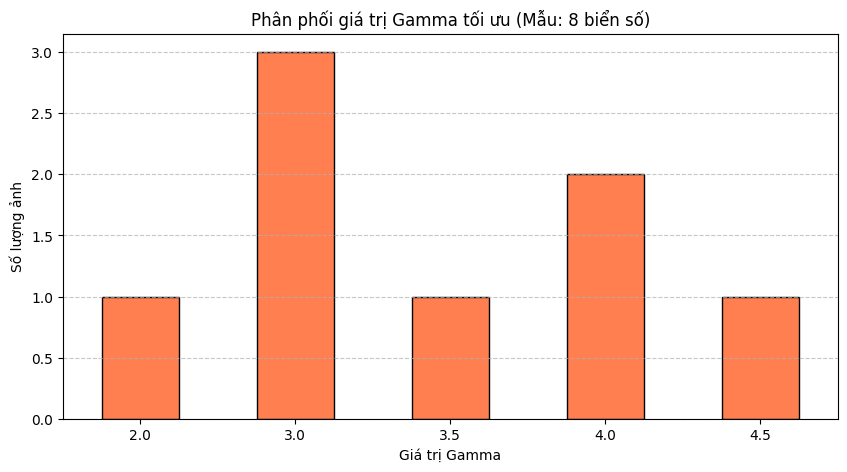

In [ ]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

print("Vui lòng chọn các ảnh (thiếu sáng) từ máy tính của bạn để thử nghiệm:")
uploaded_batch = files.upload()

if not uploaded_batch:
    print("Bạn chưa tải ảnh nào lên.")
else:
    sample_imgs = list(uploaded_batch.keys())

    print(f"\nĐang thử nghiệm Tự động tối ưu Gamma trên {len(sample_imgs)} ảnh vừa tải lên...\n")

    results_data = []

    for i, img_name in enumerate(sample_imgs):
        print(f"[{i+1}/{len(sample_imgs)}] Đang xử lý: {img_name}")
        img = cv2.imread(img_name)

        # Chạy YOLO để tìm biển số, tắt verbose để tránh nhiễu log
        yolo_res = model(img_name, verbose=False)

        plate_found = False
        for result in yolo_res:
            if plate_found:
                break
            boxes = result.boxes
            for box in boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                plate_crop = img[y1:y2, x1:x2]

                if plate_crop.shape[0] == 0 or plate_crop.shape[1] == 0:
                    continue

                # Gọi hàm tự động tối ưu Gamma
                best_text, best_conf, best_gamma, _ = auto_optimize_gamma(plate_crop, ocr)

                results_data.append({
                    'Tên ảnh': img_name,
                    'Biển số OCR': best_text,
                    'Gamma Tối Ưu': best_gamma,
                    'Độ tin cậy': round(best_conf, 4)
                })

                plate_found = True
                break

    # Tổng hợp và hiển thị kết quả
    if results_data:
        df_batch = pd.DataFrame(results_data)
        print("\n" + "="*50)
        print(" KẾT QUẢ THỬ NGHIỆM TRÊN ẢNH TẢI LÊN ")
        print("="*50)
        display(df_batch)

        # Lưu ra file CSV
        csv_path = '/content/auto_gamma_batch_uploaded_results.csv'
        df_batch.to_csv(csv_path, index=False, encoding='utf-8-sig')
        print(f"\nĐã lưu chi tiết vào file: {csv_path}")

        # Phân tích phân phối của Gamma tối ưu
        print("\nPhân phối các giá trị Gamma được chọn tối ưu:")
        gamma_counts = df_batch['Gamma Tối Ưu'].value_counts().sort_index()
        display(gamma_counts)

        # Vẽ biểu đồ
        plt.figure(figsize=(10, 5))
        gamma_counts.plot(kind='bar', color='coral', edgecolor='black')
        plt.title(f'Phân phối giá trị Gamma tối ưu (Mẫu: {len(results_data)} biển số)')
        plt.xlabel('Giá trị Gamma')
        plt.ylabel('Số lượng ảnh')
        plt.xticks(rotation=0)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
    else:
        print("\nKhông phát hiện được biển số nào trong các ảnh đã chọn.")

## 19. Tạo Web App Demo với Gradio (Chạy trực tiếp trên Colab)
Chạy cell bên dưới để cài đặt Gradio và khởi tạo giao diện web.

In [ ]:
# Cài đặt Gradio
!pip install gradio -q

In [2]:
import gradio as gr
import cv2
import numpy as np
import pandas as pd
import tempfile
from ultralytics import YOLO

# Kiểm tra và Load lại model nếu cần
try:
    demo_model = YOLO('/content/runs/plate_detection/weights/best.pt')
except:
    demo_model = YOLO('/content/best.pt')

# Hàm xử lý chính cho Gradio
def process_plate_image(img):
    if img is None:
        return None, "Vui lòng tải ảnh lên!", pd.DataFrame(), None

    # Gradio truyền vào ảnh định dạng RGB, chuyển sang BGR cho YOLO và OpenCV
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img_result = img.copy() # Ảnh để vẽ kết quả hiển thị lên web (RGB)

    # 1. Chạy YOLO tìm biển số
    results = demo_model(img_bgr, verbose=False)

    detected_texts = []
    csv_data = []

    for result in results:
        boxes = result.boxes
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            plate_crop = img_bgr[y1:y2, x1:x2]

            if plate_crop.shape[0] == 0 or plate_crop.shape[1] == 0:
                continue

            # 2. Chạy Auto Optimize Gamma + PaddleOCR (Tự động tăng cường ảnh thiếu sáng)
            best_text, best_conf, best_gamma, _ = auto_optimize_gamma(plate_crop, ocr)

            # 3. Vẽ bounding box và text lên ảnh kết quả
            cv2.rectangle(img_result, (x1, y1), (x2, y2), (255, 165, 0), 2)
            label = f"{best_text} (Conf: {best_conf:.2f})"
            # Vẽ nền đen cho chữ dễ đọc
            (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
            cv2.rectangle(img_result, (x1, y1 - 25), (x1 + w, y1), (255, 165, 0), -1)
            cv2.putText(img_result, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

            # Thêm vào danh sách tóm tắt và bảng CSV
            stt = len(csv_data) + 1
            detected_texts.append(f"✅ Biển số {stt}: **{best_text}** | Gamma tối ưu: {best_gamma} | Độ tin cậy: {best_conf:.2f}")
            csv_data.append({
                'STT': stt,
                'Biển số': best_text,
                'Gamma Tối Ưu': best_gamma,
                'Độ tin cậy OCR': round(best_conf, 4),
                'Tọa độ (x1,y1,x2,y2)': f"({x1}, {y1}, {x2}, {y2})"
            })

    if not detected_texts:
        summary = "❌ Không phát hiện thấy biển số nào trong ảnh."
        df = pd.DataFrame()
        csv_path = None
    else:
        summary = "\n".join(detected_texts)
        df = pd.DataFrame(csv_data)

        # Lưu ra file CSV tạm để tải về
        temp_file = tempfile.NamedTemporaryFile(delete=False, suffix=".csv", mode="w", encoding="utf-8-sig")
        df.to_csv(temp_file.name, index=False)
        temp_file.close()
        csv_path = temp_file.name

    return img_result, summary, df, csv_path

# Thiết kế giao diện Web với Gradio Blocks
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🚗 Ứng dụng Nhận diện Biển số xe Toàn Diện")
    gr.Markdown("Tích hợp **YOLOv11**, **PaddleOCR**, **Tự động tối ưu Gamma & CLAHE** trong điều kiện thiếu sáng, và **Xuất file CSV**.")

    with gr.Row():
        with gr.Column(scale=1):
            input_image = gr.Image(type="numpy", label="Tải ảnh lên")
            submit_btn = gr.Button("🔍 Nhận diện Biển số", variant="primary")

        with gr.Column(scale=1):
            output_image = gr.Image(type="numpy", label="Ảnh Kết quả")
            output_text = gr.Markdown(label="Thông tin tóm tắt")
            output_df = gr.Dataframe(label="Bảng chi tiết thông số")
            output_csv = gr.File(label="Tải kết quả CSV")

    submit_btn.click(fn=process_plate_image, inputs=input_image, outputs=[output_image, output_text, output_df, output_csv])

# Khởi chạy Gradio (share=True để tạo link public chia sẻ được)
print("Đang khởi động Web App...")
demo.launch(share=True, debug=False)


ModuleNotFoundError: No module named 'ultralytics'

## 20. Hướng dẫn Đưa ứng dụng lên Hugging Face Spaces (Chạy vĩnh viễn)

Đường link public của Colab Gradio thường chỉ tồn tại tạm thời. Để ứng dụng chạy vĩnh viễn, chuyên nghiệp và miễn phí 24/7, bạn có thể deploy lên nền tảng **Hugging Face Spaces**.

### Bước 1: Tạo Space mới
1. Đăng nhập hoặc tạo tài khoản tại [Hugging Face Spaces](https://huggingface.co/spaces).
2. Nhấn nút **Create new Space**.
3. Điền **Space name** (ví dụ: `license-plate-ocr-vn`).
4. Ở mục **Space SDK**, hãy chọn **Gradio**.
5. Đặt quyền hiển thị là **Public** và bấm **Create Space**.

### Bước 2: Chuẩn bị các file cần thiết
Hugging Face cần bạn cung cấp các file cơ bản sau để có thể tự động build ứng dụng:

1. **`best.pt`**: Tải file mô hình YOLO mà bạn đã train lên.
2. **`requirements.txt`**: Khai báo các thư viện môi trường cần thiết.
3. **`app.py`**: Chứa toàn bộ mã nguồn Python ghép lại từ các cell trên.

### Bước 3: Tạo nội dung cho `requirements.txt`
Trên giao diện Hugging Face Space (Tab **Files**), bấm **Add file** -> **Create a new file**, đặt tên là `requirements.txt` và dán nội dung sau:
```text
gradio
ultralytics
paddlepaddle==2.6.2
paddleocr>=2.0.1
opencv-python-headless
pandas
matplotlib
numpy<2.0.0
```
*(Lưu ý: Hugging Face bản Free chỉ có CPU, nên ta dùng `paddlepaddle` thay vì bản GPU để tránh lỗi)*.

### Bước 4: Tạo nội dung cho `app.py`
Tạo tiếp một file tên là `app.py` và dán mã nguồn tổng hợp lại ứng dụng của bạn. File này về cơ bản sẽ gom phần import, các hàm xử lý (`enhance_low_light_image`, `auto_optimize_gamma`), khởi tạo OCR & YOLO, hàm `process_plate_image` và khối `gr.Blocks()` ở cell cuối cùng của bạn lại với nhau.

_Mẹo nhỏ:_ Trong file `app.py`, sửa lại đường dẫn load model thành `./best.pt` (vì file model giờ sẽ nằm cùng thư mục với `app.py`). Và ở dòng cuối `demo.launch(...)` bạn chỉ cần để `demo.launch()` là đủ.

### Bước 5: Build và Tận hưởng
Sau khi bạn **Commit** các file lên, Hugging Face sẽ tự động tải thư viện và thiết lập môi trường (Trạng thái hiển thị là *Building*).
Đợi khoảng vài phút, khi trạng thái chuyển sang màu xanh **Running**, ứng dụng web của bạn đã hoàn thiện và sẽ chạy vĩnh viễn trên tên miền của Hugging Face!

## 21. Xử lý nhận diện biển số trên Video

Phần này sẽ hướng dẫn bạn cách áp dụng mô hình nhận diện (YOLO + PaddleOCR) để xử lý một đoạn video. Khung hình (frame) sẽ được trích xuất, nhận diện, vẽ bounding box kèm kết quả OCR, và cuối cùng xuất ra một file video hoàn chỉnh.

In [ ]:
import cv2
from google.colab import files
from tqdm import tqdm

print("Vui lòng tải lên một đoạn video ngắn (khuyến nghị < 10 giây để test):")
uploaded_video = files.upload()

if uploaded_video:
    input_video_path = list(uploaded_video.keys())[0]
    output_video_path = 'output_video.mp4'

    # Khởi tạo VideoCapture
    cap = cv2.VideoCapture(input_video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Khởi tạo VideoWriter để lưu kết quả
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    print(f"\nĐang xử lý video: {total_frames} frames...")

    # Xử lý từng frame với thanh tiến trình
    for _ in tqdm(range(total_frames), desc="Processing Video"):
        ret, frame = cap.read()
        if not ret:
            break

        # 1. Chạy YOLO tìm biển số trên frame
        results = model(frame, verbose=False)

        for result in results:
            for box in result.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                plate_crop = frame[y1:y2, x1:x2]

                if plate_crop.shape[0] == 0 or plate_crop.shape[1] == 0:
                    continue

                # 2. Chạy Auto Optimize Gamma + PaddleOCR
                best_text, best_conf, best_gamma, _ = auto_optimize_gamma(plate_crop, ocr)

                # 3. Vẽ bounding box và text lên frame
                cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 165, 0), 2)
                label = f"{best_text} ({best_conf:.2f})"
                # Tạo viền đen cho chữ để dễ đọc hơn
                (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
                cv2.rectangle(frame, (x1, y1 - 25), (x1 + w, y1), (255, 165, 0), -1)
                cv2.putText(frame, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

        # Ghi frame đã xử lý vào video đầu ra
        out.write(frame)

    # Giải phóng tài nguyên
    cap.release()
    out.release()

    print("\nHoàn tất! Đang tải video kết quả về máy tính của bạn...")
    files.download(output_video_path)
else:
    print("Bạn chưa tải video nào lên.")

Vui lòng tải lên một đoạn video ngắn (khuyến nghị < 10 giây để test):


Saving vid3.mp4 to vid3 (1).mp4

Đang xử lý video: 251 frames...


Processing Video:   0%|          | 0/251 [00:00<?, ?it/s]

  [Auto Optimize] Đang tự động tìm Gamma tốt nhất...
[2026/06/21 19:52:59] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 19:52:59] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.024152755737304688
[2026/06/21 19:52:59] ppocr DEBUG: rec_res num  : 0, elapsed : 1.430511474609375e-06
[2026/06/21 19:52:59] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 19:52:59] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.013736248016357422
[2026/06/21 19:52:59] ppocr DEBUG: rec_res num  : 0, elapsed : 1.430511474609375e-06
[2026/06/21 19:52:59] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 19:52:59] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.013813495635986328
[2026/06/21 19:52:59] ppocr DEBUG: rec_res num  : 0, elapsed : 1.430511474609375e-06
[2026/06/21 19:52:59] ppocr WARNING: Since the 

Processing Video:   0%|          | 1/251 [00:01<07:48,  1.88s/it]

...

  [Auto Optimize] Đang tự động tìm Gamma tốt nhất...
[2026/06/21 19:53:03] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 19:53:03] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.02350926399230957
[2026/06/21 19:53:03] ppocr DEBUG: rec_res num  : 0, elapsed : 7.152557373046875e-07
[2026/06/21 19:53:03] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 19:53:03] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.014213085174560547
[2026/06/21 19:53:03] ppocr DEBUG: rec_res num  : 0, elapsed : 9.5367431640625e-07
[2026/06/21 19:53:03] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 19:53:03] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.014051437377929688
[2026/06/21 19:53:03] ppocr DEBUG: rec_res num  : 0, elapsed : 1.1920928955078125e-06
[2026/06/21 19:53:03] ppocr WARNING: Since the an

Processing Video:   1%|          | 3/251 [00:04<05:02,  1.22s/it]

  [Auto Optimize] Đang tự động tìm Gamma tốt nhất...
[2026/06/21 19:53:03] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 19:53:03] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.022958755493164062
[2026/06/21 19:53:03] ppocr DEBUG: rec_res num  : 1, elapsed : 0.05674028396606445
[2026/06/21 19:53:03] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 19:53:03] ppocr DEBUG: dt_boxes num : 2, elapsed : 0.022853612899780273
[2026/06/21 19:53:03] ppocr DEBUG: rec_res num  : 2, elapsed : 0.08207225799560547
[2026/06/21 19:53:03] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 19:53:03] ppocr DEBUG: dt_boxes num : 2, elapsed : 0.02315044403076172
[2026/06/21 19:53:04] ppocr DEBUG: rec_res num  : 2, elapsed : 0.08297061920166016
[2026/06/21 19:53:04] ppocr WARNING: Since the angle c

Processing Video:   2%|▏         | 4/251 [00:08<09:44,  2.37s/it]

  [Auto Optimize] Đang tự động tìm Gamma tốt nhất...
[2026/06/21 19:53:07] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 19:53:07] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.02156972885131836
[2026/06/21 19:53:07] ppocr DEBUG: rec_res num  : 0, elapsed : 1.1920928955078125e-06
[2026/06/21 19:53:07] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 19:53:07] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.014168262481689453
[2026/06/21 19:53:07] ppocr DEBUG: rec_res num  : 0, elapsed : 9.5367431640625e-07
[2026/06/21 19:53:07] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/06/21 19:53:07] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.013038396835327148
[2026/06/21 19:53:07] ppocr DEBUG: rec_res num  : 0, elapsed : 1.430511474609375e-06
[2026/06/21 19:53:07] ppocr WARNING: Since the an

In [ ]:
from google.colab import files

# Tải lại file video kết quả
video_path = '/content/output_video.mp4'
print(f"Đang tải {video_path} về máy...")
files.download(video_path)


In [ ]:
import cv2
from google.colab import files
from tqdm import tqdm

print("Vui lòng tải lên một đoạn video ngắn (khuyến nghị < 10 giây để test):")
uploaded_video = files.upload()

if uploaded_video:
    input_video_path = list(uploaded_video.keys())[0]
    output_video_path = 'output_video.mp4'

    # Khởi tạo VideoCapture
    cap = cv2.VideoCapture(input_video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Khởi tạo VideoWriter để lưu kết quả
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    print(f"\nĐang xử lý video: {total_frames} frames...")

    # Xử lý từng frame với thanh tiến trình
    for _ in tqdm(range(total_frames), desc="Processing Video"):
        ret, frame = cap.read()
        if not ret:
            break

        # 1. Chạy YOLO tìm biển số trên frame
        results = model(frame, verbose=False)

        for result in results:
            for box in result.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                plate_crop = frame[y1:y2, x1:x2]

                if plate_crop.shape[0] == 0 or plate_crop.shape[1] == 0:
                    continue

                # 2. Chạy Auto Optimize Gamma + PaddleOCR (nếu muốn chạy nhanh có thể bỏ hàm auto_optimize và dùng ocr trực tiếp)
                best_text, best_conf, best_gamma, _ = auto_optimize_gamma(plate_crop, ocr)

                # 3. Vẽ bounding box và text lên frame
                cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 165, 0), 2)
                label = f"{best_text} ({best_conf:.2f})"
                # Tạo viền đen cho chữ để dễ đọc hơn
                (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
                cv2.rectangle(frame, (x1, y1 - 25), (x1 + w, y1), (255, 165, 0), -1)
                cv2.putText(frame, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

        # Ghi frame đã xử lý vào video đầu ra
        out.write(frame)

    # Giải phóng tài nguyên
    cap.release()
    out.release()

    print("\nHoàn tất! Đang tải video kết quả về máy tính của bạn...")
    files.download(output_video_path)
else:
    print("Bạn chưa tải video nào lên.")

Vui lòng tải lên một đoạn video ngắn (khuyến nghị < 10 giây để test):


KeyboardInterrupt: 

In [ ]:
from google.colab import files

# Tải lại file video kết quả
video_path = '/content/output_video.mp4'
print(f"Đang tải {video_path} về máy...")
files.download(video_path)


Đang tải /content/output_video.mp4 về máy...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>